
Correlation with Yield Stress:
Static Yield Stress      1.000000
Cement                   0.335204
NANO CLAY                0.288924
Open Time                0.287477
Fiber Length             0.260881
Fine Aggregate           0.208021
Silica Fume              0.171247
VMA                      0.169101
Fly Ash                  0.119834
Fiber Volume Fraction    0.108652
Accelerator              0.033799
Retarder                -0.090200
Metakaolin              -0.092125
Superplasticizer        -0.228218
Water                   -0.239010
Water/Binder Ratio      -0.363880
Name: Static Yield Stress, dtype: float64


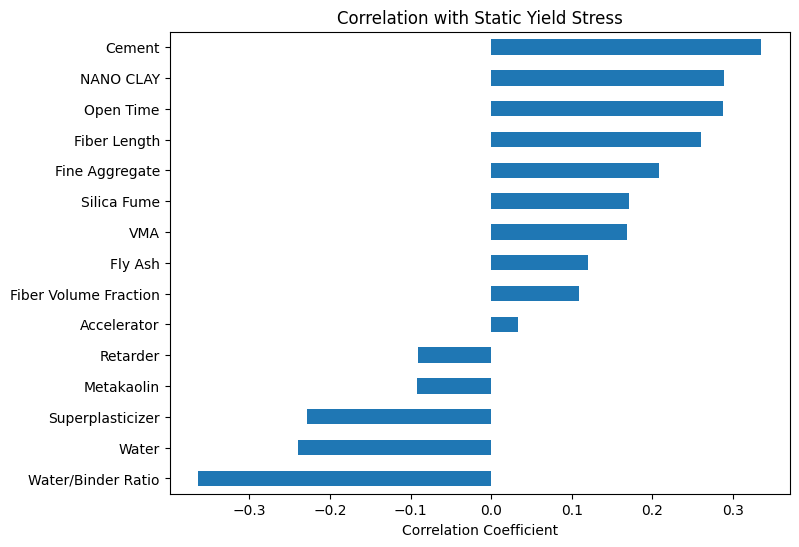


Correlation Matrix:
                       Cement  Fly Ash  Silica Fume  Metakaolin  Water  \
Cement                  1.000   -0.436        0.294      -0.336 -0.625   
Fly Ash                -0.436    1.000        0.140      -0.028 -0.086   
Silica Fume             0.294    0.140        1.000      -0.147 -0.805   
Metakaolin             -0.336   -0.028       -0.147       1.000  0.183   
Water                  -0.625   -0.086       -0.805       0.183  1.000   
Fine Aggregate          0.730   -0.167        0.352      -0.333 -0.565   
Superplasticizer        0.065    0.256        0.698       0.055 -0.656   
VMA                     0.310    0.184       -0.217      -0.070 -0.085   
Accelerator             0.026    0.108        0.286      -0.042 -0.230   
Retarder                0.150    0.036        0.426      -0.062 -0.430   
Fiber Length            0.192    0.573        0.329      -0.153 -0.265   
Fiber Volume Fraction  -0.077    0.165       -0.277      -0.163  0.381   
Water/Binder Rati

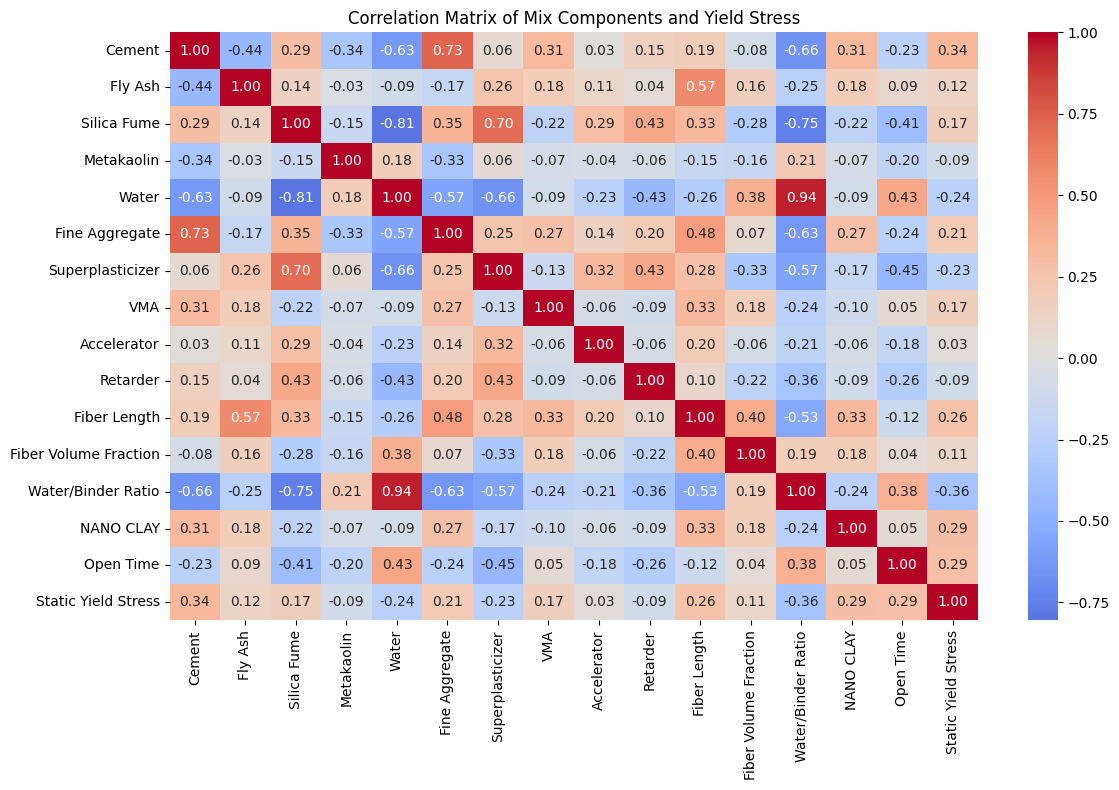


Test R² = 0.829

Feature Importance:
                  Feature  Importance
14              Open Time    0.378135
0                  Cement    0.105501
11  Fiber Volume Fraction    0.099598
4                   Water    0.096816
6        Superplasticizer    0.071429
12     Water/Binder Ratio    0.065178
10           Fiber Length    0.044993
5          Fine Aggregate    0.031066
2             Silica Fume    0.028025
8             Accelerator    0.025776
1                 Fly Ash    0.022012
13              NANO CLAY    0.017478
7                     VMA    0.007938
9                Retarder    0.006028
3              Metakaolin    0.000027


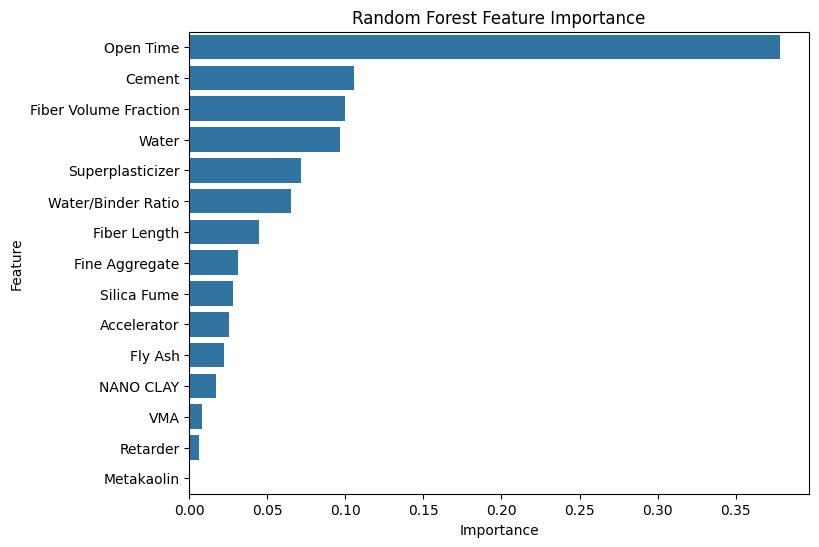

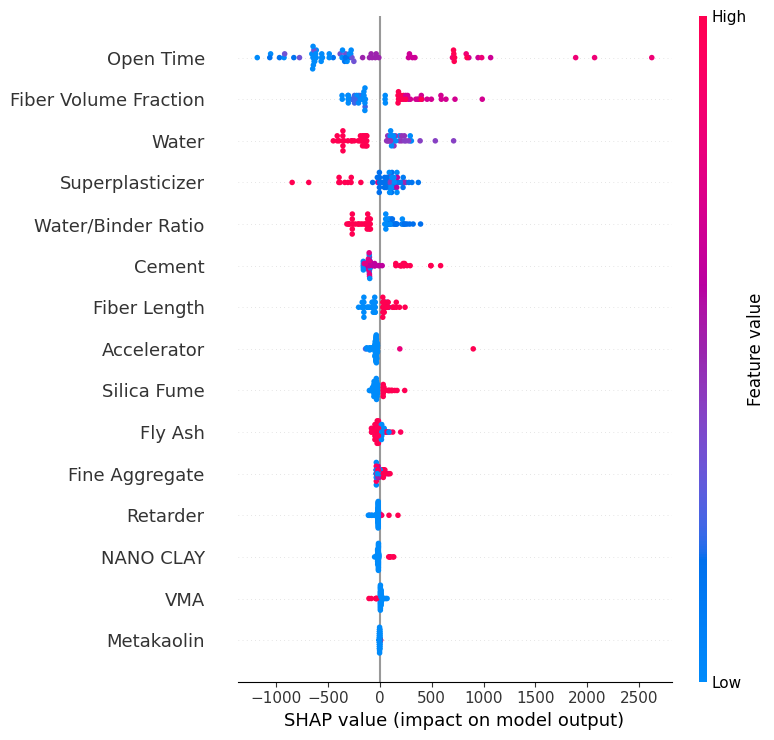

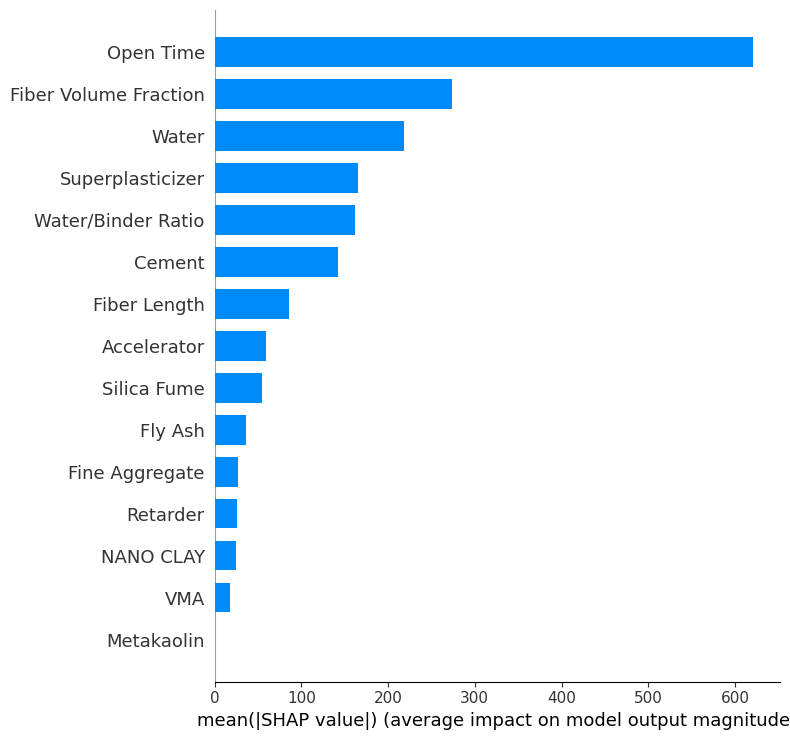


SHAP Importance Ranking:
                  Feature  Mean |SHAP|
14              Open Time   620.834407
11  Fiber Volume Fraction   273.171331
4                   Water   218.538909
6        Superplasticizer   164.846091
12     Water/Binder Ratio   162.354978
0                  Cement   142.155422
10           Fiber Length    86.194848
8             Accelerator    59.786642
2             Silica Fume    54.458887
1                 Fly Ash    35.957945
5          Fine Aggregate    26.699008
9                Retarder    26.319751
13              NANO CLAY    24.585776
7                     VMA    18.316946
3              Metakaolin     0.955357


In [ ]:
# =====================================================
# EFFECT OF MIX COMPONENTS ON STATIC YIELD STRESS
# =====================================================

# Install SHAP if needed
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import shap

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("rheology dataset(Static Yield stress only).csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Target column
target = "Static Yield Stress"

# Features
X = df.drop(columns=[target])
y = df[target]

# =====================================================
# CORRELATION ANALYSIS
# =====================================================

corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)

print("\nCorrelation with Yield Stress:")
print(corr)

plt.figure(figsize=(8,6))
corr.drop(target).sort_values().plot(kind='barh')
plt.title("Correlation with Static Yield Stress")
plt.xlabel("Correlation Coefficient")
plt.show()


# =====================================================
# CORRELATION MATRIX
# =====================================================

corr_matrix = df.corr(numeric_only=True)

# Print values
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Mix Components and Yield Stress")
plt.tight_layout()
plt.show()

# =====================================================
# RANDOM FOREST FEATURE IMPORTANCE
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("\nTest R² =", round(r2_score(y_test, pred),3))

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(8,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Random Forest Feature Importance")
plt.show()

# =====================================================
# SHAP ANALYSIS
# =====================================================

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)

# Bar plot
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

# =====================================================
# SHAP VALUES TABLE
# =====================================================

mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_shap
}).sort_values(
    by='Mean |SHAP|',
    ascending=False
)

print("\nSHAP Importance Ranking:")
print(shap_importance)